# 04 — Model training

XGBoost, Random Forest and Ridge on each branch, tuned by search over a
TimeSeriesSplit of the training period only. The test period, January 2022 to
December 2024, is evaluated once. Scores: RMSE, R² and MAE.

Input: `data/processed/features_*.csv` · Output: `results/04_*`

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

BRANCHES = ["original", "seasonal", "trend"]
SUFFIX = {"original": "", "seasonal": "_S", "trend": "_T"}
data = {b: pd.read_csv(f"../data/processed/features_{b}.csv",
                       index_col="date", parse_dates=True) for b in BRANCHES}


def split(df):
    X = df.drop(columns=["target", "split"])
    train = df["split"] == "train"
    return X[train], X[~train], df.loc[train, "target"], df.loc[~train, "target"]


for b, df in data.items():
    Xtr, Xte, ytr, yte = split(df)
    print(f"{b:9s} {Xtr.shape[1]:2d} features | "
          f"train {len(Xtr)} ({Xtr.index.min():%Y-%m}..{Xtr.index.max():%Y-%m}) | "
          f"test {len(Xte)} ({Xte.index.min():%Y-%m}..{Xte.index.max():%Y-%m})")

original  12 features | train 238 (2002-03..2021-12) | test 36 (2022-01..2024-12)
seasonal  14 features | train 238 (2002-03..2021-12) | test 36 (2022-01..2024-12)
trend      6 features | train 238 (2002-03..2021-12) | test 36 (2022-01..2024-12)


## Hyperparameter tuning

Randomised search (40 draws) for the tree models, grid search over the penalty for
Ridge, all scored by RMSE on a five-fold TimeSeriesSplit of the training period.
Ridge is standardised inside its pipeline, so scaling uses training statistics only.

In [2]:
SEED = 0
CV = TimeSeriesSplit(n_splits=5)

MODELS = {
    "XGBoost": (XGBRegressor(random_state=SEED, n_jobs=1), {
        "n_estimators": randint(200, 800), "max_depth": randint(2, 7),
        "learning_rate": loguniform(0.01, 0.2), "subsample": uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.6, 0.4), "min_child_weight": randint(1, 11)}),
    "RandomForest": (RandomForestRegressor(random_state=SEED, n_jobs=1), {
        "n_estimators": randint(300, 800), "max_depth": [None, 4, 6, 8, 12],
        "min_samples_leaf": randint(1, 11), "max_features": ["sqrt", 0.5, 1.0]}),
    "Ridge": (make_pipeline(StandardScaler(), Ridge()), {
        "ridge__alpha": np.logspace(-4, 3, 50)}),
}


def tune(name, X, y):
    est, space = MODELS[name]
    if name == "Ridge":
        search = GridSearchCV(est, space, cv=CV,
                              scoring="neg_mean_squared_error", n_jobs=-1)
    else:
        search = RandomizedSearchCV(est, space, n_iter=40, cv=CV,
                                    scoring="neg_mean_squared_error",
                                    random_state=SEED, n_jobs=-1)
    return search.fit(X, y)


best_params = {}
for b, df in data.items():
    Xtr, _, ytr, _ = split(df)
    for name in MODELS:
        search = tune(name, Xtr, ytr)
        best_params[(b, name)] = search.best_params_
        print(f"{b:9s} {name:12s} CV RMSE {np.sqrt(-search.best_score_):.4f}")

original  XGBoost      CV RMSE 0.0492


original  RandomForest CV RMSE 0.0498
original  Ridge        CV RMSE 0.0521


seasonal  XGBoost      CV RMSE 0.0444


seasonal  RandomForest CV RMSE 0.0462
seasonal  Ridge        CV RMSE 0.0446


trend     XGBoost      CV RMSE 0.0077


trend     RandomForest CV RMSE 0.0084
trend     Ridge        CV RMSE 0.0020


## Test period

Two baselines alongside the models. **Persistence** predicts last month's value.
**Climatology** predicts the training-period mean for the calendar month.

In [3]:
def make_model(b, name, seed=SEED):
    est = clone(MODELS[name][0]).set_params(**best_params[(b, name)])
    if name != "Ridge":
        est.set_params(random_state=seed)
    return est


def scores(y, p):
    return dict(RMSE=np.sqrt(mean_squared_error(y, p)), R2=r2_score(y, p),
                MAE=mean_absolute_error(y, p))


def baselines(b, df, test_mask):
    y = df["target"]
    persistence = df[f"NDVI{SUFFIX[b]}_lag1"]
    clim = y[~test_mask].groupby(y[~test_mask].index.month).mean()
    climatology = pd.Series(y.index.month.map(clim), index=y.index)
    return {"persistence": persistence, "climatology": climatology}


rows, predictions = [], {}
for b, df in data.items():
    Xtr, Xte, ytr, yte = split(df)
    test = df["split"] == "test"
    for name in MODELS:
        p = make_model(b, name).fit(Xtr, ytr).predict(Xte)
        predictions[(b, name)] = pd.Series(p, index=Xte.index)
        rows.append(dict(branch=b, model=name, **scores(yte, p)))
    for name, s in baselines(b, df, test).items():
        predictions[(b, name)] = s[test]
        rows.append(dict(branch=b, model=name, **scores(yte, s[test])))

test_scores = pd.DataFrame(rows)
ORDER = ["XGBoost", "RandomForest", "Ridge", "persistence", "climatology"]
for metric in ["RMSE", "R2", "MAE"]:
    print(f"\n{metric}")
    print(test_scores.pivot(index="model", columns="branch", values=metric)
                     .loc[ORDER, BRANCHES].round(4).to_string())


RMSE
branch        original  seasonal   trend
model                                   
XGBoost         0.0550    0.0551  0.0074
RandomForest    0.0584    0.0560  0.0059
Ridge           0.0584    0.0636  0.0015
persistence     0.0972    0.0971  0.0021
climatology     0.0753    0.0734  0.0406

R2
branch        original  seasonal   trend
model                                   
XGBoost         0.8776    0.8742  0.8680
RandomForest    0.8619    0.8701  0.9144
Ridge           0.8619    0.8324  0.9942
persistence     0.6181    0.6095  0.9893
climatology     0.7711    0.7769 -2.9970

MAE
branch        original  seasonal   trend
model                                   
XGBoost         0.0368    0.0388  0.0064
RandomForest    0.0385    0.0380  0.0049
Ridge           0.0456    0.0478  0.0013
persistence     0.0697    0.0696  0.0017
climatology     0.0473    0.0481  0.0351


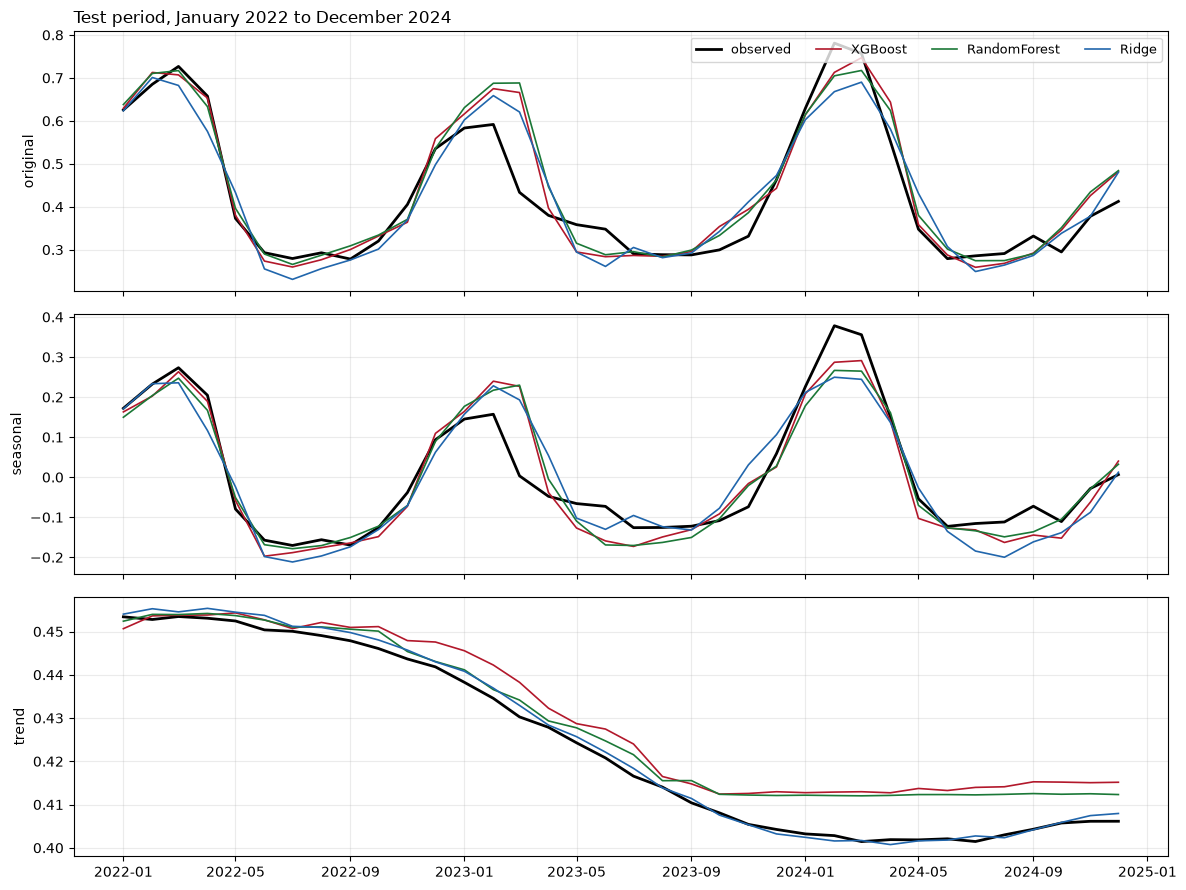

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
colors = {"XGBoost": "#b2182b", "RandomForest": "#1b7837", "Ridge": "#2166ac"}
for ax, b in zip(axes, BRANCHES):
    _, Xte, _, yte = split(data[b])
    ax.plot(yte.index, yte, color="black", lw=2, label="observed")
    for name, c in colors.items():
        ax.plot(yte.index, predictions[(b, name)], color=c, lw=1.2, label=name)
    ax.set_ylabel(b)
    ax.grid(alpha=0.25)
axes[0].legend(ncol=4, loc="upper right", fontsize=9)
axes[0].set_title("Test period, January 2022 to December 2024", loc="left")
fig.tight_layout()
fig.savefig("../figures/04_test_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

## Noise floor

Each tree model refitted with 20 seeds at its tuned parameters. A difference smaller
than the seed-to-seed standard deviation is indistinguishable from refitting. Ridge
is deterministic.

In [5]:
floor = []
for b, df in data.items():
    Xtr, Xte, ytr, yte = split(df)
    for name in MODELS:
        seeds = [SEED] if name == "Ridge" else range(20)
        runs = [scores(yte, make_model(b, name, s).fit(Xtr, ytr).predict(Xte)) for s in seeds]
        floor.append(dict(branch=b, model=name,
                          RMSE_mean=np.mean([r["RMSE"] for r in runs]),
                          RMSE_sd=np.std([r["RMSE"] for r in runs]),
                          R2_mean=np.mean([r["R2"] for r in runs]),
                          R2_sd=np.std([r["R2"] for r in runs])))

noise_floor = pd.DataFrame(floor)
print(noise_floor.round(4).to_string(index=False))

  branch        model  RMSE_mean  RMSE_sd  R2_mean  R2_sd
original      XGBoost     0.0550   0.0005   0.8778 0.0023
original RandomForest     0.0581   0.0004   0.8633 0.0020
original        Ridge     0.0584   0.0000   0.8619 0.0000
seasonal      XGBoost     0.0552   0.0038   0.8731 0.0171
seasonal RandomForest     0.0556   0.0004   0.8722 0.0020
seasonal        Ridge     0.0636   0.0000   0.8324 0.0000
   trend      XGBoost     0.0071   0.0004   0.8773 0.0155
   trend RandomForest     0.0059   0.0001   0.9159 0.0020
   trend        Ridge     0.0015   0.0000   0.9942 0.0000


## Rolling-origin evaluation

Five consecutive three-year test windows, each model trained on everything before
its window. Hyperparameters are the ones tuned above; for windows before 2022 they
were tuned on data that includes the window.

In [6]:
WINDOWS = [("2010-01-01", "2012-12-01"), ("2013-01-01", "2015-12-01"),
           ("2016-01-01", "2018-12-01"), ("2019-01-01", "2021-12-01"),
           ("2022-01-01", "2024-12-01")]

folds = []
for b, df in data.items():
    X, y = df.drop(columns=["target", "split"]), df["target"]
    for start, end in WINDOWS:
        tr, te = df.index < start, (df.index >= start) & (df.index <= end)
        for name in MODELS:
            p = make_model(b, name).fit(X[tr], y[tr]).predict(X[te])
            folds.append(dict(branch=b, window=start[:4] + "-" + end[2:4], model=name,
                              RMSE=np.sqrt(mean_squared_error(y[te], p)),
                              R2=r2_score(y[te], p)))
        for name, s in baselines(b, df, ~tr).items():
            folds.append(dict(branch=b, window=start[:4] + "-" + end[2:4], model=name,
                              RMSE=np.sqrt(mean_squared_error(y[te], s[te])),
                              R2=r2_score(y[te], s[te])))

rolling = pd.DataFrame(folds)
order = ["XGBoost", "RandomForest", "Ridge", "persistence", "climatology"]
for b in BRANCHES:
    for metric, digits in [("RMSE", 4), ("R2", 3)]:
        t = rolling[rolling.branch == b].pivot(index="model", columns="window",
                                               values=metric).loc[order]
        t["mean"], t["sd"] = t.mean(axis=1), t.std(axis=1)
        print(f"\n{b} — {metric}"); print(t.round(digits).to_string())


original — RMSE
window        2010-12  2013-15  2016-18  2019-21  2022-24    mean      sd
model                                                                    
XGBoost        0.0538   0.0398   0.0448   0.0419   0.0550  0.0471  0.0069
RandomForest   0.0562   0.0342   0.0457   0.0397   0.0584  0.0468  0.0104
Ridge          0.0576   0.0413   0.0497   0.0435   0.0584  0.0501  0.0079
persistence    0.0999   0.1034   0.1098   0.1018   0.0972  0.1024  0.0047
climatology    0.0758   0.0356   0.0586   0.0523   0.0753  0.0595  0.0169

original — R2
window        2010-12  2013-15  2016-18  2019-21  2022-24   mean     sd
model                                                                  
XGBoost         0.898    0.941    0.939    0.943    0.878  0.920  0.030
RandomForest    0.889    0.957    0.937    0.949    0.862  0.919  0.041
Ridge           0.883    0.937    0.925    0.938    0.862  0.909  0.035
persistence     0.648    0.602    0.635    0.664    0.618  0.633  0.024
climatology     0.

## Reconstruction

Seasonal plus trend predictions, compared with the model fitted to the original
series directly.

In [7]:
y_orig = split(data["original"])[3]
recon = []
for name in MODELS:
    p = (predictions[("seasonal", name)] + predictions[("trend", name)]).reindex(y_orig.index)
    direct = test_scores.query("branch == 'original' and model == @name").iloc[0]
    recon.append(dict(model=name,
                      RMSE_direct=direct.RMSE, RMSE_reconstructed=np.sqrt(mean_squared_error(y_orig, p)),
                      R2_direct=direct.R2, R2_reconstructed=r2_score(y_orig, p)))
print(pd.DataFrame(recon).round(4).to_string(index=False))

       model  RMSE_direct  RMSE_reconstructed  R2_direct  R2_reconstructed
     XGBoost       0.0550              0.0539     0.8776            0.8824
RandomForest       0.0584              0.0548     0.8619            0.8788
       Ridge       0.0584              0.0637     0.8619            0.8359


## Saving

In [8]:
json.dump({f"{b}|{m}": {k: (v.item() if hasattr(v, "item") else v) for k, v in p.items()}
           for (b, m), p in best_params.items()},
          open("../results/04_best_params.json", "w"), indent=2)
test_scores.to_csv("../results/04_test_scores.csv", index=False)
noise_floor.to_csv("../results/04_noise_floor.csv", index=False)
rolling.to_csv("../results/04_rolling_origin.csv", index=False)
pd.DataFrame({f"{b}|{m}": s for (b, m), s in predictions.items()}) \
  .to_csv("../results/04_test_predictions.csv")
print("saved")

saved
